In [33]:
import math
import numpy as np
import matplotlib.pyplot as plt
import graphviz
%matplotlib inline

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

In [34]:
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

,Registration State,Violation Description,count
0,CA,Bus Stop,50180
1,NJ,Double Parking,50217
2,NY,Fire Hydrant,50115
3,TX,Double Parking,50221


In [35]:
!apt-get install graphviz -q
!pip install graphviz -q

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [36]:
def f(x):
  return 3*x**2 -4*x + 5

In [37]:
f(3.0)

20.0

In [38]:
xs = np.arange(-5,5,0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [39]:
f(xs)

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

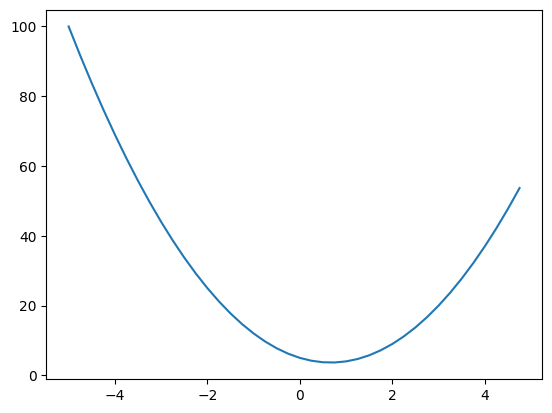

In [40]:
ys = f(xs)
plt.plot(xs, ys)

In [41]:
h = 0.00000001

In [42]:
x = 2/3
(f(x+h)-f(x))/h

0.0

In [43]:
#more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [44]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [45]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [46]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [47]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    # children of every expression
    self._prev = set(_children)
    self._op = _op
    self.label = label

  # a way to print out a nicer looking expression basically more formatting
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    return out

a = Value(2.0, label='a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label ='d'
f = Value(-2.0); f.label = 'f'
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [48]:
d._prev
L._prev

{Value(data=-2.0), Value(data=4.0)}

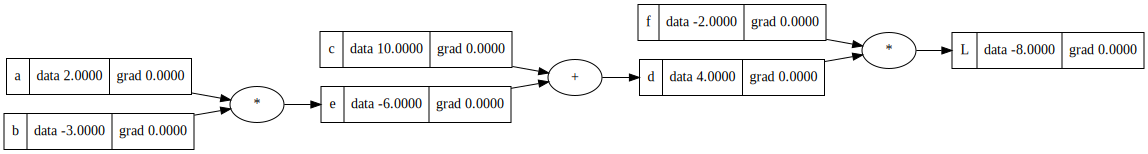

In [49]:
from graphviz import Digraph

def trace(root):
  #builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in  nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

draw_dot(L)

In [50]:
# L = d*f
# dL/dd = f
# (f(x+h)-f(x))/h

# ((d+h)*f - d*f)/h
# (d*f +h*f - d*f)/h
# (h*f)h
# f

# dL/dc
# d(d*f)/dc
# f*(dd)/dc
# f*d(e+c)/dc
# f*(de+dc)/dc
# f*(d(a*b)+dc)/dc
# f*(0+1)
# f

# dL/de
# d(d*f)/de
# f*(dd)/de
# f*d(e+c)/de
# f*(de+dc)/de
# f*(1+0)
# f

# dL/da = f*d((a*b)+c)/da = fb
# dL/db = f*d((a*b)+c)/db = fa


In [51]:
L.grad = 1.
# gradient of f = dL/df = d
f.grad = 4.0
# gradient of d = dL/dd = f
d.grad = -2.0
# gradient of c = dL/dc = f
c.grad = -2.0
# gradient of e = dL/de = f
e.grad = -2.0
# gradient of a = dL/da = fb
a.grad = 6.0
# gradient of b = dL/db = fa
b.grad = -4.0

In [52]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
print(L.data)

-7.286496


In [53]:


def lol():

  h = 0.0001

  a = Value(2.0, label='a')
  b = Value(-3.0, label = 'b')
  c = Value(10.0, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label ='d'
  f = Value(-2.0); f.label = 'f'
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0+h, label = 'b')
  c = Value(10.0, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label ='d'
  # f = Value(-2.0+h); f.label = 'f'
  f = Value(-2.0); f.label = 'f'
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1)/h)

lol()

-4.000000000008441


In [54]:


def lol():

  h = 0.0001

  a = Value(2.0, label='a')
  b = Value(-3.0, label = 'b')
  c = Value(10.0, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label ='d'
  f = Value(-2.0); f.label = 'f'
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label = 'b')
  c = Value(10.0, label = 'c')
  e = a*b; e.label = 'e'
  d = e + c; d.label ='d'
  d.data += h
  f = Value(-2.0); f.label = 'f'
  L = d * f; L.label = 'L'
  L2 = L.data

  # basically printing the gradient
  print((L2 - L1)/h)

lol()

-1.9999999999953388


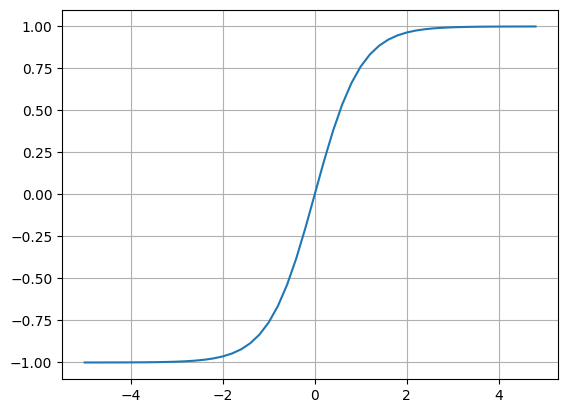

In [55]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

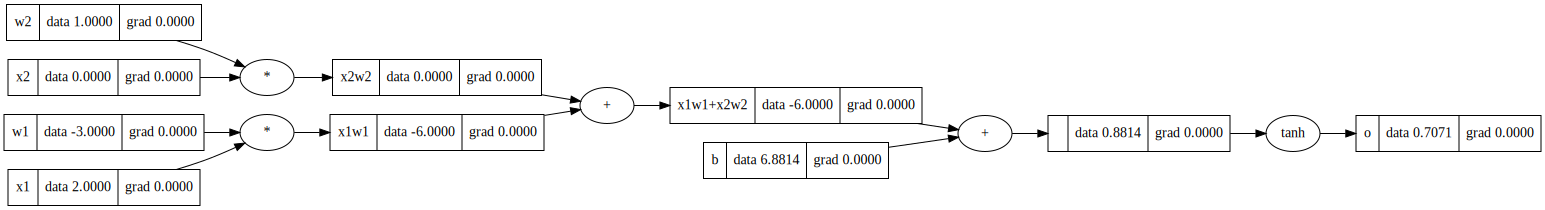

In [61]:
#inputs x1, x2
x1 = Value (2.0, label='x1')
x2 = Value (0.0, label='x2')
#weights w1, w2
w1 = Value (-3.0, label='w1')
w2 = Value (1.0, label='w2')
#bias of the neuron
b = Value (6.8813735870195432, label='b')
#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'
n = x1w1x2w2 +b; label='n'
o = n.tanh(); o.label='o'
draw_dot(o)